# Data provisioning

#### Previous notebook: [Data collection](01_data_collection.ipynb)

## Split labels into separate columns
In the original `disaster_categories.csv` file all labels per message are stored as a single string in the *categories* column, separated by semicolons. In this step, I split the labels into different columns, one per label. This is done to ensure the data is stored in a suitable format for converting each label values into numeric data type:

In [60]:
import pandas as pd

df_categories = pd.read_csv("../data/raw/original/disaster_categories.csv")
cats = df_categories[["id", "categories"]].copy()
cats_expanded = cats["categories"].str.split(";", expand=True)
row = cats_expanded.iloc[0]
category_colnames = row.apply(lambda x: x.split("-")[0])
cats_expanded.columns = category_colnames
categories = pd.concat([cats["id"], cats_expanded], axis=1)
categories.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
1,7,related-1,request-0,offer-0,aid_related-1,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-1,floods-0,storm-1,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
2,8,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
3,9,related-1,request-1,offer-0,aid_related-1,medical_help-0,medical_products-1,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
4,12,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0


As we can see from the output above, the categories column is now separated in multiple small label-based columns. Each column stores the name of the label and a binary number that represents whether the label applies to the message (1) or not (0).

## Convert columns to numeric values
In this step, I go through all *label - number* values, remove the text, keep only the numeric value and cast it into an integer to ensure all target variables are correctly stored:

In [61]:
for column in categories.columns:
    if column != "id":
        categories[column] = categories[column].str.split("-").str[-1].astype(int)

print(categories.shape)
print(categories.info())

(26248, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26248 entries, 0 to 26247
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      26248 non-null  int64
 1   related                 26248 non-null  int64
 2   request                 26248 non-null  int64
 3   offer                   26248 non-null  int64
 4   aid_related             26248 non-null  int64
 5   medical_help            26248 non-null  int64
 6   medical_products        26248 non-null  int64
 7   search_and_rescue       26248 non-null  int64
 8   security                26248 non-null  int64
 9   military                26248 non-null  int64
 10  child_alone             26248 non-null  int64
 11  water                   26248 non-null  int64
 12  food                    26248 non-null  int64
 13  shelter                 26248 non-null  int64
 14  clothing                26248 non-null  int64
 15  money  

From the output above, we can see that after splitting and casting, the categories dataset consists of 26 248 rows and 37 columns - one id column and 36 labels, all integers. This ensures all labels were properly separated as its current count equals the original dataset documentation.

## Check all unique values per column
After converting all column values to integers, I will go through all columns, except the id, and store all unique values per label to verify whether all columns contain binary values (1 and 0):

In [62]:
binary_check = {}

for col in categories.columns:
    if col == "id":
        continue
    vals = sorted(categories[col].unique().tolist())
    binary_check[col] = vals

binary_check

{'related': [0, 1, 2],
 'request': [0, 1],
 'offer': [0, 1],
 'aid_related': [0, 1],
 'medical_help': [0, 1],
 'medical_products': [0, 1],
 'search_and_rescue': [0, 1],
 'security': [0, 1],
 'military': [0, 1],
 'child_alone': [0],
 'water': [0, 1],
 'food': [0, 1],
 'shelter': [0, 1],
 'clothing': [0, 1],
 'money': [0, 1],
 'missing_people': [0, 1],
 'refugees': [0, 1],
 'death': [0, 1],
 'other_aid': [0, 1],
 'infrastructure_related': [0, 1],
 'transport': [0, 1],
 'buildings': [0, 1],
 'electricity': [0, 1],
 'tools': [0, 1],
 'hospitals': [0, 1],
 'shops': [0, 1],
 'aid_centers': [0, 1],
 'other_infrastructure': [0, 1],
 'weather_related': [0, 1],
 'floods': [0, 1],
 'storm': [0, 1],
 'fire': [0, 1],
 'earthquake': [0, 1],
 'cold': [0, 1],
 'other_weather': [0, 1],
 'direct_report': [0, 1]}

As we can see from the results above, the most columns contain binary values, except for the *related* one which consists of the numbers 0,1 and 2. Additionally, we can see that the *child_alone* column only consists of 0, which is a clear indication that this label will be removed later as it does not apply to any of the messages and does not bring any valuable information for the training stage.

In the original dataset documentation, it is mentioned that the 2s in the column *related* represent the answer "unsure" for messages that cannot be clearly categorized. Due to the sensitivity of the child-related messages and the potential risk of developing a model that could identify at-risk minors all *child_alone* annotations are 0.

## Check all labels of the non-binary samples
To get a better understanding of what the "unsure" messages represent, I will extract all labels for those specific messages and check their annotations to understand whether they behave as related and have other needs or completely act as a completely separate category:

In [63]:
rel2 = categories[categories["related"] == 2].copy()
other_cols = [c for c in categories.columns if c not in ["id", "related"]]
rel2["other_positive"] = rel2[other_cols].gt(0).any(axis=1)
print(rel2["other_positive"].value_counts())

other_positive
False    193
Name: count, dtype: int64


The results above show that all other labels of those "unsure" messages are negative and do not provide information about any specific help needed. To ensure all labels are in a binary format and are properly annotated, I will remove those samples.

### Check binary vs non-binary sample distribution
Before dropping the examples from the dataset, I will calculate the % of Binary vs Non-binary "related" labels, to check and document how much data I will lose:

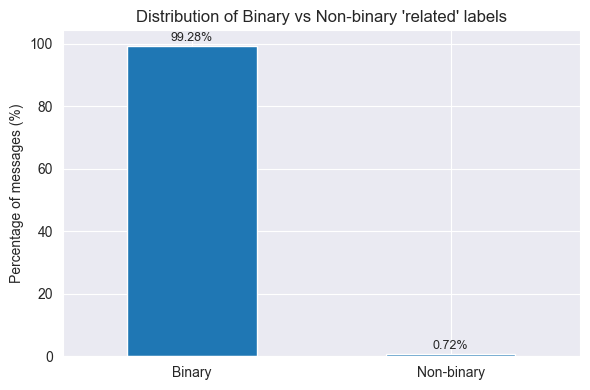

In [64]:
import matplotlib.pyplot as plt

related_2_rows = categories[categories["related"] == 2]
ids_related_2 = related_2_rows["id"].unique()
total_ids = categories["id"].nunique()
non_binary_ids = len(ids_related_2)
binary_ids = total_ids - non_binary_ids
counts = pd.Series({"Binary": binary_ids,"Non-binary": non_binary_ids})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(6, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Distribution of Binary vs Non-binary 'related' labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)
for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

The bar chart above shows that the messages with *related = 2* represent a very small proportion (0.72%) of the whole dataset, which clearly indicates that the value behaves as an outlier class. Removing these rows will not introduce substantial data loss and will keep *related* category easier to interpret for modeling.

## Drop non-binary samples
In this step, I will drop all *related = 2* rows and check the remaining binary distribution:

In [65]:
ids_to_drop = rel2["id"].unique()
categories_clean = categories[~categories["id"].isin(ids_to_drop)].copy()
categories_clean["related"].value_counts()

related
1    19929
0     6125
Name: count, dtype: int64

After removing the "unsure" samples, the *related* column consists of 19 929 related messages and 6 125 not related. The results confirm that all non-binary rows were removed from the dataset.

## Label aggregation
In the [Data collection notebook](01_data_collection.ipynb) were detected 68 duplicate in both `disaster_messages.csv` and `disaster_categories.csv`. The duplicates appear because one message was annotated by more than one person. To address this problem, I decided to apply aggregation, which combines all labels from duplicates related to a specific message. If a label was marked as positive in at least one row will remain positive in the final label vector:

In [66]:
categories_agg = categories_clean.groupby("id", as_index=False).max()
categories_agg.to_csv("../data/raw/removed_duplicates/disaster_categories.csv", index=False)
print("Duplicate ids after aggregation:",categories_agg["id"].duplicated().sum())

Duplicate ids after aggregation: 0


To ensure that the label aggregation was applied successfully, I print the sum of all detected duplicates, which in this case is 0. The deduplicated file is saved in a sub-folder called `removed_duplicates`.

## Inspect file
In this step, I will inspect the deduplicated categories dataset to confirm the final shape and data types before merging it with the `disaster_messages.csv`:

In [67]:
print(categories_agg.shape)
print(categories_agg.info())

(25992, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      25992 non-null  int64
 1   related                 25992 non-null  int64
 2   request                 25992 non-null  int64
 3   offer                   25992 non-null  int64
 4   aid_related             25992 non-null  int64
 5   medical_help            25992 non-null  int64
 6   medical_products        25992 non-null  int64
 7   search_and_rescue       25992 non-null  int64
 8   security                25992 non-null  int64
 9   military                25992 non-null  int64
 10  child_alone             25992 non-null  int64
 11  water                   25992 non-null  int64
 12  food                    25992 non-null  int64
 13  shelter                 25992 non-null  int64
 14  clothing                25992 non-null  int64
 15  money  

In [68]:
categories_agg.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,1,0,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,8,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,1,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The results above show that, after aggregation, the `disaster_categories.csv` consists of 25 992 labels and 37 columns - all integers. All labels are split in separate columns and have binary values, which indicates that the two files are ready to be merged.

## Check messages with vs without labels distribution
Before merging the two disaster datasets, I will create a simple bar chart to visualize the distribution of messages with vs without labels. This step is important, as it reports the percentage of messages that will be lost after applying inner join.

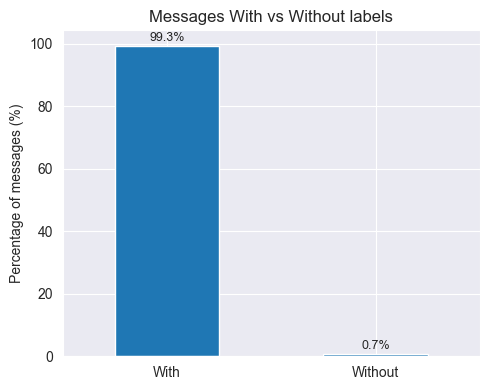

In [69]:
msg = pd.read_csv("../data/raw/removed_duplicates/disaster_messages.csv")
cat = pd.read_csv("../data/raw/removed_duplicates/disaster_categories.csv")
n_total = msg["id"].nunique()
ids_with_cat = set(cat["id"])
n_with = msg["id"].isin(ids_with_cat).sum()
n_without = n_total - n_with
counts = pd.Series({"With": n_with,"Without": n_without})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(5, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Messages With vs Without labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)

for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

The bar chart above shows that a very small fraction (0.7%) of messages do not have labels. This indicates  that the data loss after merging is minimal and acceptable.

## Merge disaster dataset
In this step, I will merge the two deduplicated disaster files on their shared *id* column. I will use inner join, which will automatically drop all messages that do not have labels in the category dataset. Finally, I will inspect the structure of the raw disaster dataset and save it to ensure the file can be reused in other notebooks:

In [70]:
from functools import reduce

dfs = [msg, cat]
disaster_df = reduce(lambda left, right: pd.merge(left, right, on="id", how="inner"), dfs)
print(disaster_df.shape)
print(disaster_df.info())

(25992, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      25992 non-null  int64 
 1   message                 25992 non-null  object
 2   original                10021 non-null  object
 3   genre                   25992 non-null  object
 4   related                 25992 non-null  int64 
 5   request                 25992 non-null  int64 
 6   offer                   25992 non-null  int64 
 7   aid_related             25992 non-null  int64 
 8   medical_help            25992 non-null  int64 
 9   medical_products        25992 non-null  int64 
 10  search_and_rescue       25992 non-null  int64 
 11  security                25992 non-null  int64 
 12  military                25992 non-null  int64 
 13  child_alone             25992 non-null  int64 
 14  water                   25992 non-null  in

In [71]:
disaster_df.to_csv("../data/raw/disaster_dataset.csv", index=False)
disaster_df.head()

,id,message,original,genre,related,request,offer,aid_related,medical_help,medical_products,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,Weather update - a cold front from Cuba that could pass over Haiti,Un front froid se retrouve sur Cuba ce matin. Il pourrait traverser Haiti demain. Des averses de pluie isolee sont encore prevues sur notre region ce soi,direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ak timoun yo. Mesi se john jean depi Monben kwochi.",direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,direct,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,12,"says: west side of Haiti, rest of the country today and tonight",facade ouest d Haiti et le reste du pays aujourd hui et ce soir,direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The results show that the raw merged dataset consists of 25 992 rows and 40 columns - one unique identifier, the message in its original language and in English, the genre of the message and 36 binary labels (0/1). Most of the columns in the dataset have numeric data type and only 3 - *message, original* and *genre* are stored as text. To read more about the structure of the dataset check: [disaster dataset dictionary](../docs/Data%20dictionary.md).

## Data quality check before cleaning
The exploratory data analysis focuses on assessing and improving the quality of the disaster dataset by focusing the following questions:
 - Are there labels that are too rare?
 - How balanced is the label distribution?
 - Are there messages with no labels?
 - How many labels do most messages have?
 - Are there any missing values and what is the reason behind them?
 - What is the average message length?
 - What fraction of messages is originally in English?
#### Messages per label
In this step, I will compute and visualize the percentage of messages per label. To get the percentage, I will use the *calculate_label_message_percentage* function from the `helper.py` file, which was created to store reusable code. The results will help me identify rare labels and assess the class imbalance:

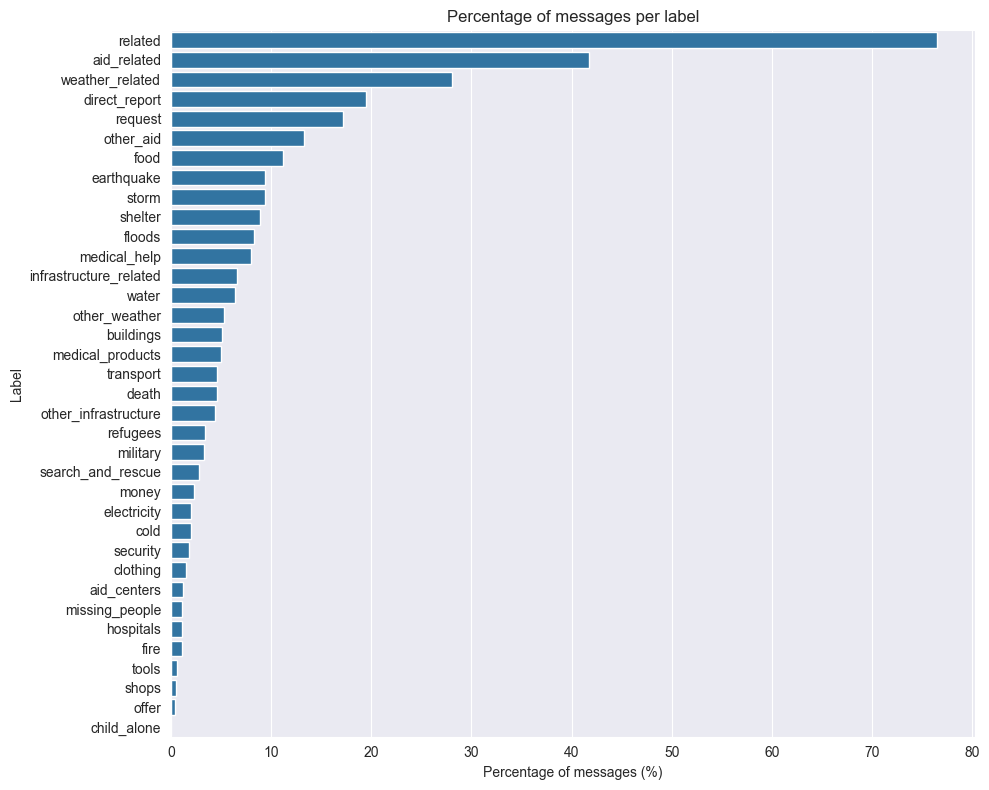

In [72]:
import seaborn as sns
from utilities import helper

label_pct = helper.calculate_label_message_percentage(disaster_df)
plt.figure(figsize=(10, 8))
sns.barplot(x=label_pct.values,y=label_pct.index)
plt.xlabel("Percentage of messages (%)")
plt.ylabel("Label")
plt.title("Percentage of messages per label")
plt.tight_layout()
plt.show()

The bar chart above shows that the dataset is strongly imbalanced - some labels are more common than others. Categories such as *related, aid_related* and *weather_related* appear in a large fraction of messages, while the more specific ones are around or below 10%. There are some very rare labels such as *tools, shops* and *offer*. As already explained in the beginning of this notebook, the *child_alone* column was restricted due to sensitivity. This column will be removed in the cleaning stage.

#### Labels per message
In this step, I will analyse the labels per message distribution. First, I use the `helper.py` file from utilities to select only the label columns from the dataset and compute the *n_labels*, which is the sum of all positive labels per row. Due to visualisation purposes, I group all calculations into 5 ranges - 0, 1-10, 11-20, 21-30 and 31+, and visualise the percentage of messages per group:

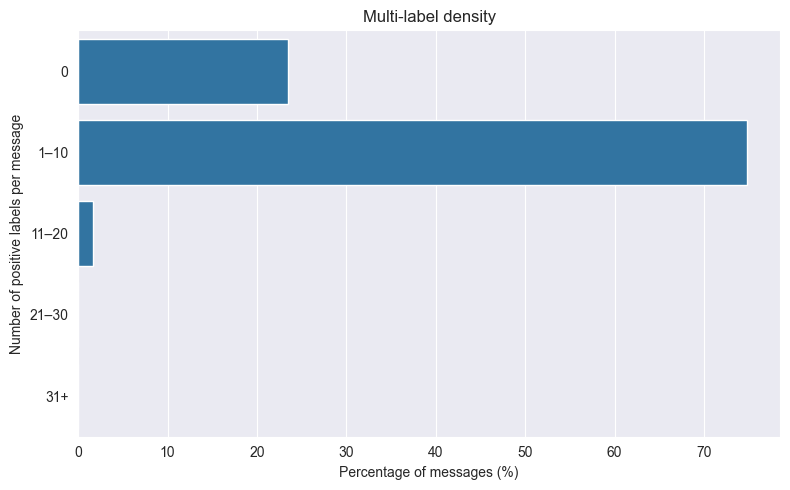

In [73]:
from utilities import helper

label_cols = helper.get_label_columns(disaster_df)
disaster_df["n_labels"] = disaster_df[label_cols].sum(axis=1)
max_possible = len(label_cols)
bins = [-0.1, 0.5, 10.5, 20.5, 30.5, max_possible + 0.5]
range_labels = ["0", "1–10", "11–20", "21–30", "31+"]
disaster_df["label_range"] = pd.cut(disaster_df["n_labels"],bins=bins,labels=range_labels,include_lowest=True)
range_counts = disaster_df["label_range"].value_counts().sort_index()
range_pct = (range_counts / len(disaster_df) * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=range_pct.values,y=range_pct.index,orient="h")
plt.xlabel("Percentage of messages (%)")
plt.ylabel("Number of positive labels per message")
plt.title("Multi-label density")
plt.tight_layout()
plt.show()

From the bar chart above, I can see that the majority of the messages have labels in the range 1-10, while very few have more than 10. However, more than 20% of the messages do not have any labels at all, which is expected and normal, as most of the time organizations might receive messages that do not express a concrete need. These all-negative label examples confirm that the dataset reflects realistic crisis situations and they will be treated as valid samples. There are no messages with more than 20 labels.

#### Check missingness
In this step, I will inspect the percentage of missing data for each column in tha dataset. If a column has no detected *NaN* values, it will not be included in the final bar chart. This information will guide my decisions on how to properly handle missing data in later stages:
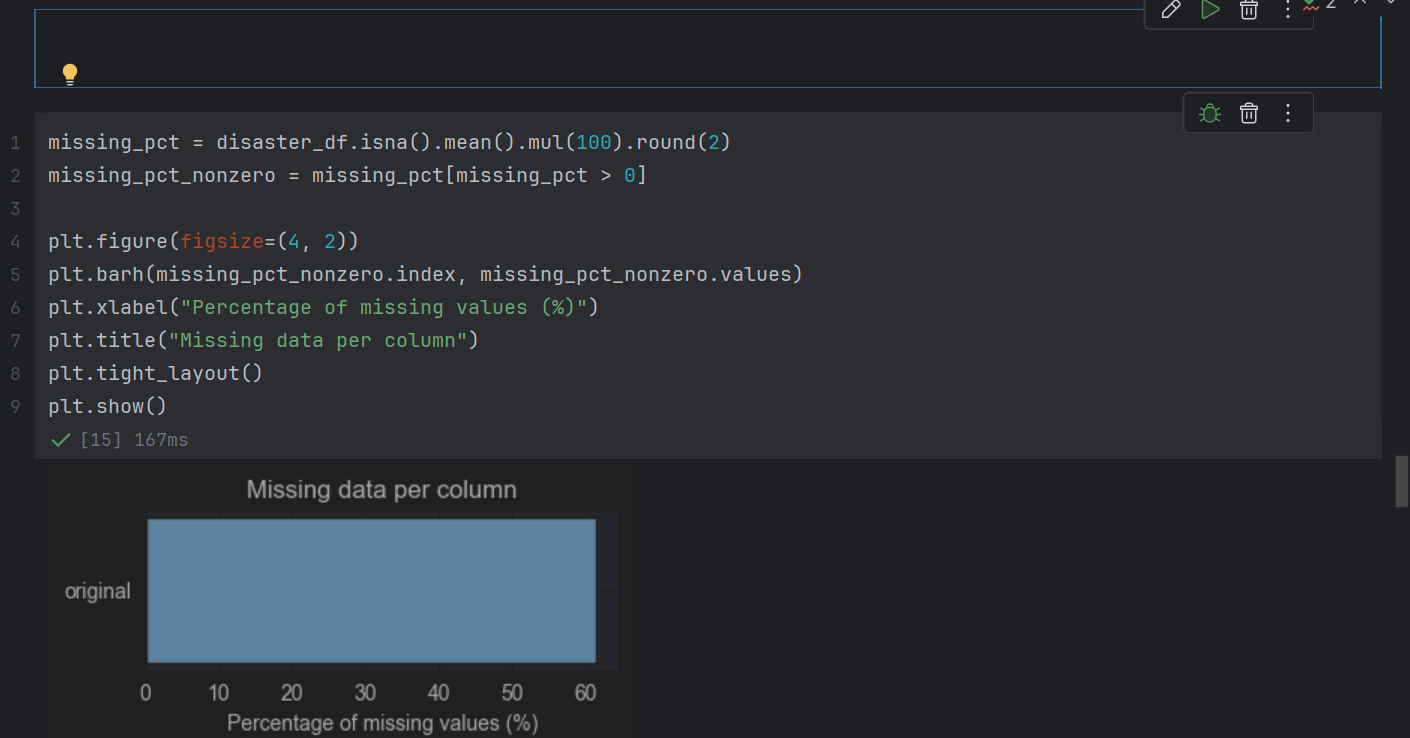

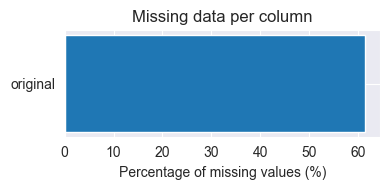

In [74]:
missing_pct = disaster_df.isna().mean().mul(100).round(2)
missing_pct_nonzero = missing_pct[missing_pct > 0]

plt.figure(figsize=(4, 2))
plt.barh(missing_pct_nonzero.index, missing_pct_nonzero.values)
plt.xlabel("Percentage of missing values (%)")
plt.title("Missing data per column")
plt.tight_layout()
plt.show()

The results above show that the only column, with detected missingness of more than 60%, is *original*, which was already expected. This column stores the original message before translating it to English, but if the message is originally written in English, the column stays empty. Since this project focuses only on the English version of the messages, this column does not provide any useful information, therefore, it will be removed.

#### Check message length
In this step, I will inspect message length based on the amount of words detected in each text. The plots below will help me identify extremely short or long messages and guide my decision on whether I should remove those outliers:

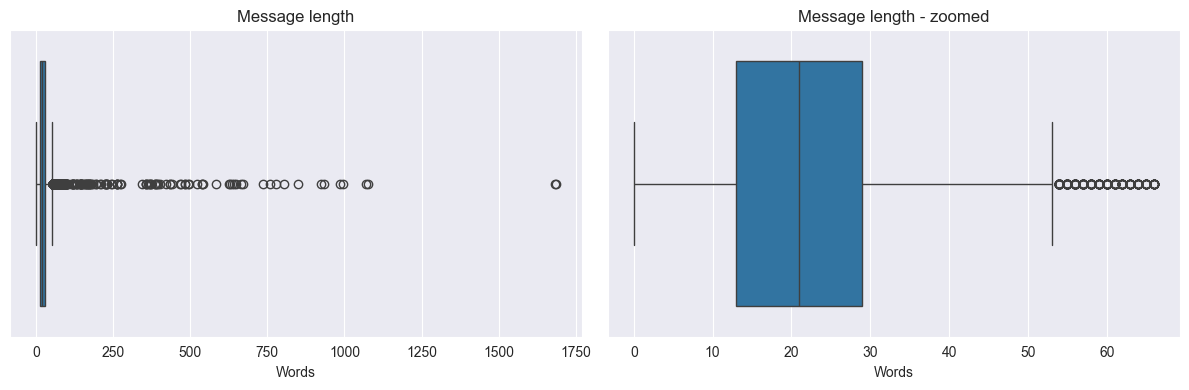

In [75]:
disaster_df["msg_len"] = disaster_df["message"].str.split().str.len()
p99 = disaster_df["msg_len"].quantile(0.99)
short_df = disaster_df[disaster_df["msg_len"] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=disaster_df["msg_len"], ax=axes[0])
axes[0].set_title("Message length")
axes[0].set_xlabel("Words")

sns.boxplot(x=short_df["msg_len"], ax=axes[1])
axes[1].set_title("Message length - zoomed")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

In [76]:
word_stats = disaster_df["msg_len"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
word_stats

count    25992.000000
mean        23.892929
std         32.297461
min          0.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         45.000000
99%         66.000000
max       1686.000000
Name: msg_len, dtype: float64

This message-length analysis shows that most of the messages in the dataset are short - the average is 21 words, while 99% stay below 66 words. However, the boxplots clearly show that there are some extreme cases, such as completely empty messages (no words detected) and very long messages up to 1686 words. This clearly suggests that most messages in the dataset fall in a range of 5-66 words.

#### Detect the amount of extremely long and short messages
Do inspect extreme messages, I created two boolean masks - for those with at most 2 words and for those with at least 100 words. These cut-offs were based on the observed length range mentioned in the previous step, where most messages fall roughly between 5 and 60 words. Messages with at most 2 words are much smaller and could potentially not contain any valuable information, while messages with at least 100 words are way beyond the range limit and might be irrelevant for organizations like the Red Cross.

In [77]:
short_mask = disaster_df["msg_len"] <=2
long_mask  = disaster_df["msg_len"] >= 100
n_total = len(disaster_df)
n_short = short_mask.sum()
n_long  = long_mask.sum()

print(f"Extremely short: {n_short}")
print(f"Extremely long: {n_long}")

Extremely short: 13
Extremely long: 108


The results show that there are 13 extremely short and 108 extremely long messages. To gain a better understanding of whether those messages are worth keeping, I will visually examine some samples. The table below shows the full text of all 13 short samples:

In [78]:
pd.set_option("display.max_colwidth", None)
disaster_df.loc[short_mask, ["message"]]

,message
6736,paklascencion##s
7621,"world visionw.agency.usaid,pam"
8310,Aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa
8775,Nokia.com http://ea.mobile.nokia.com/ea/graphics
12051,
12080,PIDE .
15502,(http://www.guardian.co.uk/global-development/2013/jan/16/somali-ngos-mogadishu-street-children)
16327,#NAME?
21216,Website: http://www.childfund.org/emergency_updates/
21326,See http://www.iwpr.net/index.pl?local_caucasus/caucasus_panorama.html


From the table above, we can see that most of these extremely short messages are clearly non-informative. They do not represent real crisis communication and would only add noise. This is why, these samples will be removed later in the dataset cleaning step.

Now, I will inspect 3 random samples from the extremely long detected messages:

In [145]:
pd.set_option("display.max_colwidth", None)
disaster_df.loc[long_mask, ["message"]].sample(3)

,message
15854,"The first day we had four outpatients, yesterday the number rose to 40 and today we had 70 before lunch. As Hurricane Mitch pummeled Nicaragua and Honduras, triggering flash floods and mudslides, women began counting the missing. Operation Goal: to meet the urgent needs of the 50,000 worst affected families in Assam and Bihar with food, shelter, family packs and medical services, to ensure improved quality of water over a period of four months and prepare to meet longer-term needs through necessary capacity building and disaster mitigation initiatives over a further period of six months after the emergency phase. Thankfully, heavy and steady rain completely extinguished the big forest fire in Pech valley of Konar after it destroyed 30 square kilometers (12 square miles) of jungle and 130,000 logs,"" the Taliban mouth-piece said."
24094,"To ensure trouble-free passage of flood water and prevent flooding of houses, all the necessary organizational and practical measures are being taken,"" the press service of the Oblast's Akimat said. The program requires that the reconstruction work should stick to the conbination of the reconstrctuion of urban housing and the development of urbanization; the reconstruction of rural housing and the construction of socialism news countries and the poverty-relief; the governmental management and the marketing exercise; the housing strengthening and reparing and the housing building. Workers are also preparing to purchase large quantities of tin in order to repair some of the hundreds of homes damaged by the storms. Women are able to come to the riverbed, scoop into the sand, and find water rather than walking for hours in search of the life sustaining resource. In the Labutta Township, ADRA is partnering with various donors including the United States Agency for International Development (USAID) and the Department for International Development (DFID) of the British Government to increase access to clean water among vulnerable cyclone-affected people by cleaning the local water reservoirs or 'ponds,' and providing water purification units, jerry cans, household kits, shelter materials, tool kits, and other goods prior to the end of the rainy season. Local public health authorities are instructed to educate people on how to prevent the diseases while residents living in inundated areas are warned not to defecate and throw rubbish into the water to prevent risks of waterborne diseases. Community radios are broadcasting health and hygiene messages and mobile media units are conducting social mobilisation and outreach activities in resettlement centres. Together with the ASG, the Federation's head of delegation will monitor the ongoing operation on a daily basis and actively seek to achieve optimum co-operation and co-ordination with authorities and all involved. The stock market was closed for the day, along with all schools and offices in Taiwan, railway traffic was halted and many flights were cancelled as winds of up to 144 kilometres (90 miles) per hour blew across, uprooting trees. Over the last three years, we've seen a series of reprisal killings in Hazarajat and areas to its north, as control has shifted back and forth,"" Sidney Jones, Asia director of HRW said."
20257,"Cold weather, and the crowding which results, is associated with more opportunities for person-to-person transmission of respiratory pathogens. Critical supplies include antibiotics, analgesics, personal care items and feminine hygience products, anti-malarials, vitamins and nutritional supplements, cold and cough medicines, disposable gloves, burn creams, antithelmics, wound care supplies, vaccines oral rehydration solution, and sutures and surgical supplies. Coastline Trains Back on Track Soon: Trains will be back on track between Colombo and Matara in early March but will be subject to delays until a new signaling system is installed according to the local Sunday Observer. I have my basic tools but once I ge

After inspecting the extremely long messages, I decided to keep them as they represent coherent crisis-related reports rather than noisy, non-informative long texts.

#### English vs Non-English original messages
In this step, I will compare the percentage of messages originally written in English versus translated from some other languages. To get these proportions, I use the *original* column as it is only filled when the message was originally not in English:

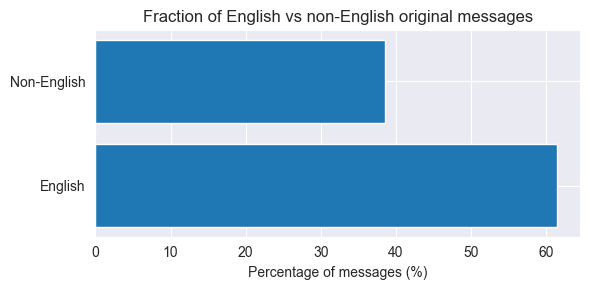

In [80]:
disaster_df["is_non_english"] = disaster_df["original"].notna()
lang_counts = disaster_df["is_non_english"].value_counts()
lang_counts.index = lang_counts.index.map({False: "English",True:  "Non-English"})
lang_pct = (lang_counts / len(disaster_df) * 100).round(2)

plt.figure(figsize=(6, 3))
plt.barh(lang_pct.index, lang_pct.values)
plt.xlabel("Percentage of messages (%)")
plt.title("Fraction of English vs non-English original messages")
plt.tight_layout()
plt.show()

The bar chart above shows that more than 60% of the messages were originally written in English, while slightly less than 40% were translated.This is important to keep in mind, as some texts might contain unusual phrasing or artefacts, which supports the need of consistent text normalization.

#### Label correlation
In this step, I inspect how often different labels appear together in the same message. I exclude the column *related* as it is the most common and will show high correlation with almost all other labels. In this heatmap, I only inspect the 20 most frequent labels:

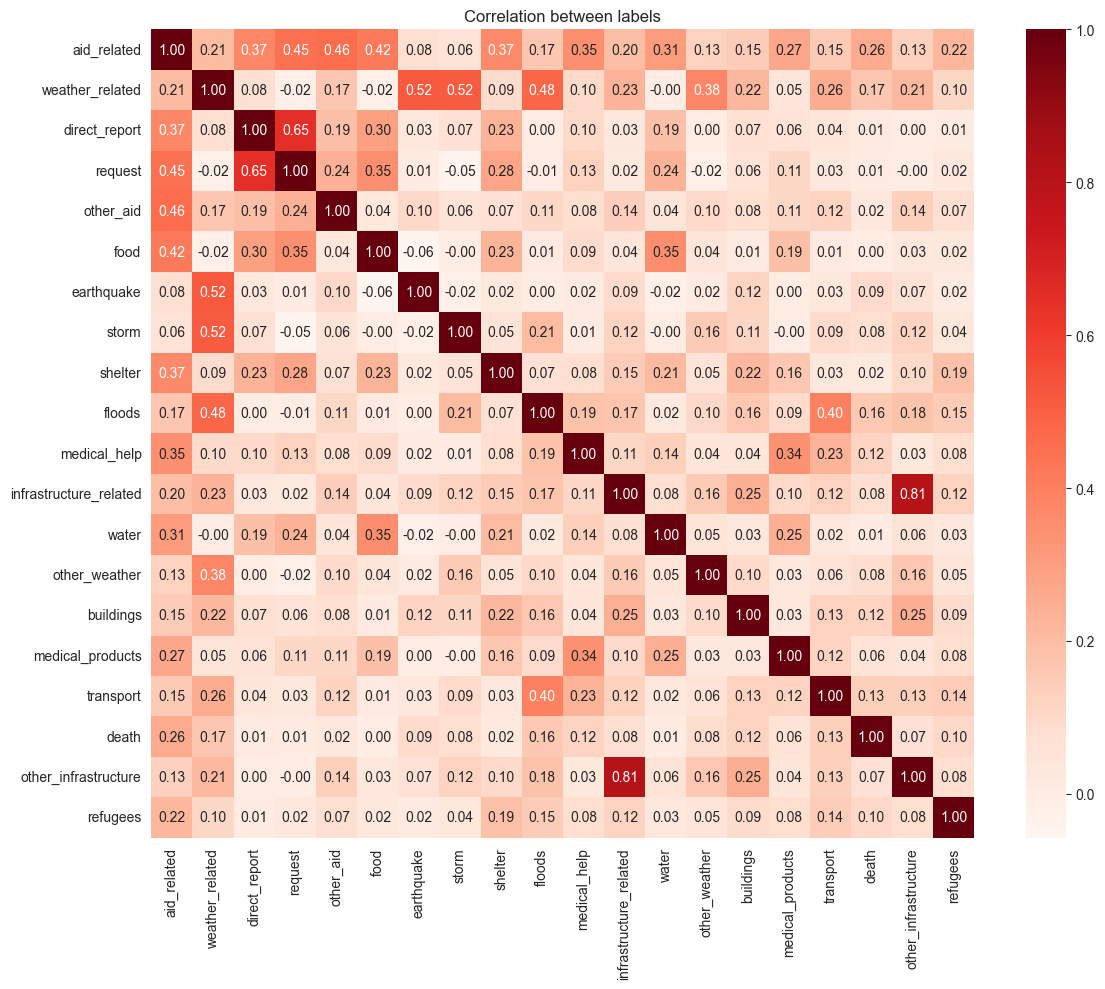

In [81]:
disaster_df = pd.read_csv("../data/raw/disaster_dataset.csv", low_memory=False)
non_label_cols = ["id", "message", "original", "genre"]
label_cols = [c for c in disaster_df.columns if c not in non_label_cols]
label_cols_no_related = [c for c in label_cols if c != "related"]
label_counts = disaster_df[label_cols_no_related].sum().sort_values(ascending=False)
top_labels = label_counts.head(20).index.tolist()

corr_small = disaster_df[top_labels].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_small,cmap="Reds", annot=True, fmt=".2f")
plt.title("Correlation between labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

From the heatmap above, we can see that most of the label pairs have low to moderate correlation, confirming this is a multi-label classification problem. Two pairs show slightly higher correlation - *direct_report - request* and *infrastructure_related - other_infrastructure*. The second pair shows a hierarchical relationship where when one is selected the other is usually selected as well.

## Cleaning dataset
In this step, I will perform data cleaning based on the insights gathered from the previous steps:
 - *child_alone* label has no positive examples due to data sensitivity
 - *original* column as the model will only use the English version and contains missing values
 - *extremely short messages* identified as non-informative and noisy

In [82]:
cols_to_drop = ["child_alone", "original"]
disaster_df = disaster_df.drop(columns=cols_to_drop)
keep_mask = ~short_mask
disaster_clean = disaster_df.loc[keep_mask].copy()
disaster_clean.to_csv("../data/final/disaster_dataset.csv",index=False)
print(disaster_clean.shape)
disaster_clean.info()

(25979, 38)
<class 'pandas.core.frame.DataFrame'>
Index: 25979 entries, 0 to 25991
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      25979 non-null  int64 
 1   message                 25979 non-null  object
 2   genre                   25979 non-null  object
 3   related                 25979 non-null  int64 
 4   request                 25979 non-null  int64 
 5   offer                   25979 non-null  int64 
 6   aid_related             25979 non-null  int64 
 7   medical_help            25979 non-null  int64 
 8   medical_products        25979 non-null  int64 
 9   search_and_rescue       25979 non-null  int64 
 10  security                25979 non-null  int64 
 11  military                25979 non-null  int64 
 12  water                   25979 non-null  int64 
 13  food                    25979 non-null  int64 
 14  shelter                 25979 non-null  int64 


The output above shows that after cleaning, the dataset consists of 25979 rows and 38 columns - one unique identifier, the English version of the message, its genre and 35 labels.

## Data quality check after cleaning
#### Check missingness after cleaning
To verify that the cleaning steps properly handled all detected issues, I will recalculate the percentage of missing values across the entire dataset. As we can see from the results below, there are no detected NaN values and the previously removed *child_alone* and *original* columns no longer appear.

In [83]:
disaster_clean.isna().mean().sort_values(ascending=False)

id                        0.0
message                   0.0
genre                     0.0
related                   0.0
request                   0.0
offer                     0.0
aid_related               0.0
medical_help              0.0
medical_products          0.0
search_and_rescue         0.0
security                  0.0
military                  0.0
water                     0.0
food                      0.0
shelter                   0.0
clothing                  0.0
money                     0.0
missing_people            0.0
refugees                  0.0
death                     0.0
other_aid                 0.0
infrastructure_related    0.0
transport                 0.0
buildings                 0.0
electricity               0.0
tools                     0.0
hospitals                 0.0
shops                     0.0
aid_centers               0.0
other_infrastructure      0.0
weather_related           0.0
floods                    0.0
storm                     0.0
fire      

#### Check message length
To verify the extremely short messages were properly dropped, I recompute the message length statistics. The min word count has increased from 0 to 3, which confirms that the cleaning removed noisy, non-informative texts and preserved the original message length.

In [84]:
word_len_clean = disaster_clean["message"].str.split().str.len()
word_len_clean.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    25979.000000
mean        23.904230
std         32.301585
min          3.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         45.000000
99%         66.000000
max       1686.000000
Name: message, dtype: float64

## Extract small inference set
Before creating the *train/vat/test* split, I will randomly extract a small 50 sample subset for inference testing. The subset will be removed from the main dataset and will be saved in the folder `final` as `disaster_inference.csv`. The small inference dataset will be used for inference testing and demonstrating the behaviour of the final model on completely unseen messages.

In [85]:
df = pd.read_csv("../data/final/disaster_dataset.csv")
df_inference = df.sample(n = 50, random_state = 42)
df_model = df.drop(df_inference.index).reset_index(drop=True)
df_inference.to_csv("../data/final/disaster_inference.csv", index=False)

print("Inference set:", df_inference.shape)
print("Modelling set:", df_model.shape)

Inference set: (50, 38)
Modelling set: (25929, 38)


## Feature selection
In this step, I select the *message* column as input feature for my models and the all remaining label columns as multi-label target. This step ensures that only relevant information is used for training.

In [86]:
feature = df_model["message"]
label_cols = helper.get_label_columns(df_model)

x = feature.copy()
y = df_model[label_cols].copy()

## Splitting into train/val/test sets
In this step, I split my data into three subsets - train (70%), validation (15%) and test (15%). First, I split the data into train/temporary subsets. Then, I split the temporary subset evenly into validation and test sets. I chose this separation as it will allow me to train and tune all models on the train/validation sets, while keeping the testing one completely unseen. Lastly, I print the number of rows in each set:

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(x,y,test_size=0.30,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42)

for name, arr in [("X_train:", X_train),("X_val:",   X_val),("X_test:",  X_test)]:
    print(name, arr.shape[0])

X_train: 18150
X_val: 3889
X_test: 3890


#### Save train/val/test sets
This step is very important, as it ensures the consistency and reproducibility across all models. The subsets are saved in separate files so that each model can use the exactly same input data during training, validation and evaluation.

In [88]:
X_train.to_csv("../data/split_data/X_train.csv", index=False)
X_val.to_csv("../data/split_data/X_val.csv", index=False)
X_test.to_csv("../data/split_data/X_test.csv", index=False)

y_train.to_csv("../data/split_data/y_train.csv", index=False)
y_val.to_csv("../data/split_data/y_val.csv", index=False)
y_test.to_csv("../data/split_data/y_test.csv", index=False)

## Text normalization

#### Converting to lowercase
The first step in the text normalization phase is to lowercase all messages. This is an important step that ensures all words with different capitalization patterns are treated as the same token. It also makes the TF-IDF representation more compact and consistent.

**Example:**
Without lowercasing, the 3 different versions of "water" would be treated as different tokens.
*Before lowercasing:* "water", "Water", "WATER"
*After lowercasing:* "water"

In [89]:
messages = X_train.copy()
lowered_messages = messages.str.lower()

df = pd.DataFrame({"original": messages, "lowercased": lowered_messages})
df.head()

,original,lowercased
23753,"The challenge for governments, with FAO assistance, is to review measures to be taken in the veterinary realm, despite the fact that ""there is currently no evidence to suggest that the novel human-to-human transmitted H1N1 influenza virus is circulating in pigs in Mexico or anywhere else in the world, reasserted FAO Chief Veterinary Officer of FAO, Mr. Joseph Domenech.","the challenge for governments, with fao assistance, is to review measures to be taken in the veterinary realm, despite the fact that ""there is currently no evidence to suggest that the novel human-to-human transmitted h1n1 influenza virus is circulating in pigs in mexico or anywhere else in the world, reasserted fao chief veterinary officer of fao, mr. joseph domenech."
13252,"They have to endure scorching heat in the day but they are drenched when it's rains, he said.","they have to endure scorching heat in the day but they are drenched when it's rains, he said."
3803,Why not do something for the people- Please check on some in need in the yard of Fanmpac Co. on National rte #1 Bwin courtyard next to Unibank.,why not do something for the people- please check on some in need in the yard of fanmpac co. on national rte #1 bwin courtyard next to unibank.
14284,"HANOI, Apr 5, 2002 (Xinhua via COMTEX) -- Fires that have been raging in Vietnam's U Minh Thuong National Park for the last 10 days destroyed more than 4,000 hectares (ha) of the country's virgin cajeput forest, the Vietnam News reported Friday.","hanoi, apr 5, 2002 (xinhua via comtex) -- fires that have been raging in vietnam's u minh thuong national park for the last 10 days destroyed more than 4,000 hectares (ha) of the country's virgin cajeput forest, the vietnam news reported friday."
5195,"Delmas 60, Argentina at the entrance. Thank you for the service. May god bless You All.","delmas 60, argentina at the entrance. thank you for the service. may god bless you all."


#### Replacing URLs and email addresses
Some messages in the dataset, contain URLs and email addresses, for references to news articles or contact details. Usually, they are not relevant for the model and can be replaced with fixed placeholder tokens that will allow the model understand there is an email or link. This will also help reducing the noise and the vocabulary size:

In [90]:
mask_urls_emails = df["lowercased"].str.contains(r"http|www\.|@\w+\.\w+", regex=True, na=False)
examples = df["lowercased"].loc[mask_urls_emails].copy()
examples_norm = examples.str.replace(r"http\S+|www\.\S+", " <url> ", regex=True)
examples_norm = examples_norm.str.replace(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " <email> ", regex=True)
df_examples = pd.DataFrame({"original": examples, "after_url_email_replacement": examples_norm})
df_examples.head()

,original,after_url_email_replacement
11904,renaissance man at the rio theatre - santa cruz news http://bit.ly/cwjshx,renaissance man at the rio theatre - santa cruz news <url>
12553,"the horrible aftermath of #sandy in harlem, nyc! http://t.co/3lby0xxz","the horrible aftermath of #sandy in harlem, nyc! <url>"
11311,"after the chile quake: unease, and wedding bells, in santiago - time http://icio.us/yb2prs","after the chile quake: unease, and wedding bells, in santiago - time <url>"
12313,halloween 2012 (@frankenstorm apocalypse - hurricane sandy w/ 2095 others) http://t.co/2jg6gpwo,halloween 2012 (@frankenstorm apocalypse - hurricane sandy w/ 2095 others) <url>
12347,"some people may be happy to see a walmart boarded up, but not for this reason. #sandy @walmart http://t.co/oz9k2o31","some people may be happy to see a walmart boarded up, but not for this reason. #sandy @walmart <url>"


#### Handling hashtags and user mentions
Some messages come from social media, which is why they might contain hashtags and user mentions, as in the last sample - #sandy and @walmart. The words in these strings can carry useful information related to the disaster or the context of the message, but the special signs "#" and "@" are not informative. To simplify the text, while preserving the important information, those symbols will be removed:

In [91]:
examples_norm = df_examples["after_url_email_replacement"].str.replace(r"#(\w+)", r" \1 ", regex=True)
examples_norm = examples_norm.str.replace(r"@(\w+)", r" \1 ", regex=True)
df_ex = pd.DataFrame({"original": df_examples["after_url_email_replacement"].values,"after_hashtag_mention_handling": examples_norm.values})
df_ex.head()

,original,after_hashtag_mention_handling
0,renaissance man at the rio theatre - santa cruz news <url>,renaissance man at the rio theatre - santa cruz news <url>
1,"the horrible aftermath of #sandy in harlem, nyc! <url>","the horrible aftermath of sandy in harlem, nyc! <url>"
2,"after the chile quake: unease, and wedding bells, in santiago - time <url>","after the chile quake: unease, and wedding bells, in santiago - time <url>"
3,halloween 2012 (@frankenstorm apocalypse - hurricane sandy w/ 2095 others) <url>,halloween 2012 ( frankenstorm apocalypse - hurricane sandy w/ 2095 others) <url>
4,"some people may be happy to see a walmart boarded up, but not for this reason. #sandy @walmart <url>","some people may be happy to see a walmart boarded up, but not for this reason. sandy walmart <url>"


#### Normalizing numbers
Many crisis messages contain numbers, specifying things like number of injured people or number of resources needed. For this project the exact number is less important and keeping each number as a separate token would increase the size of the vocabulary. This is why, I will replace each number with a "num" token:

In [92]:
examples_num =  df_ex["after_hashtag_mention_handling"].copy()
examples_num_norm = examples_num.str.replace(r"\d+", " <num> ", regex=True)
df_num = pd.DataFrame({"original": examples_num.values,"after_number_norm": examples_num_norm.values})
df_num.head()

,original,after_number_norm
0,renaissance man at the rio theatre - santa cruz news <url>,renaissance man at the rio theatre - santa cruz news <url>
1,"the horrible aftermath of sandy in harlem, nyc! <url>","the horrible aftermath of sandy in harlem, nyc! <url>"
2,"after the chile quake: unease, and wedding bells, in santiago - time <url>","after the chile quake: unease, and wedding bells, in santiago - time <url>"
3,halloween 2012 ( frankenstorm apocalypse - hurricane sandy w/ 2095 others) <url>,halloween <num> ( frankenstorm apocalypse - hurricane sandy w/ <num> others) <url>
4,"some people may be happy to see a walmart boarded up, but not for this reason. sandy walmart <url>","some people may be happy to see a walmart boarded up, but not for this reason. sandy walmart <url>"


#### Lemmatization
As a last text normalization step, I will apply lemmatization. This technique is used to reduce words to their base or dictionary form to ensure words with similar meanings are treated the same. In this project, I decided to use "spaCy", as it gives accurate part-of-speech-aware lemmas (can distinguish verbs from adjectives, etc.) and works fast.
<p style="text-align: center;">
  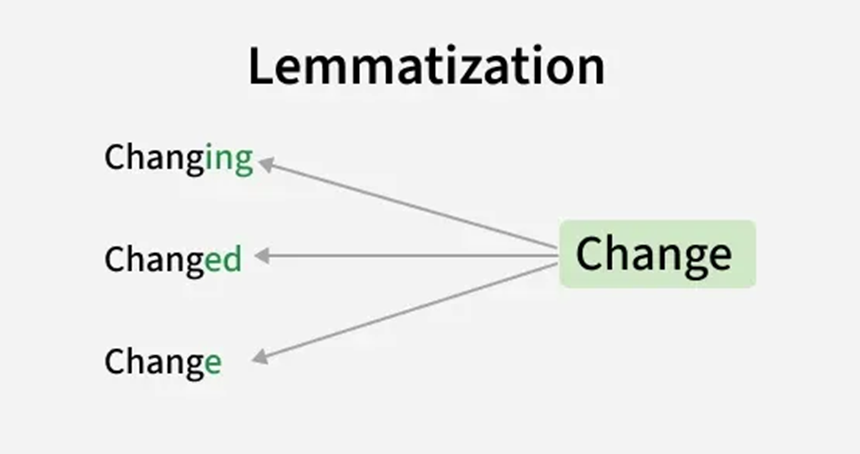
</p>
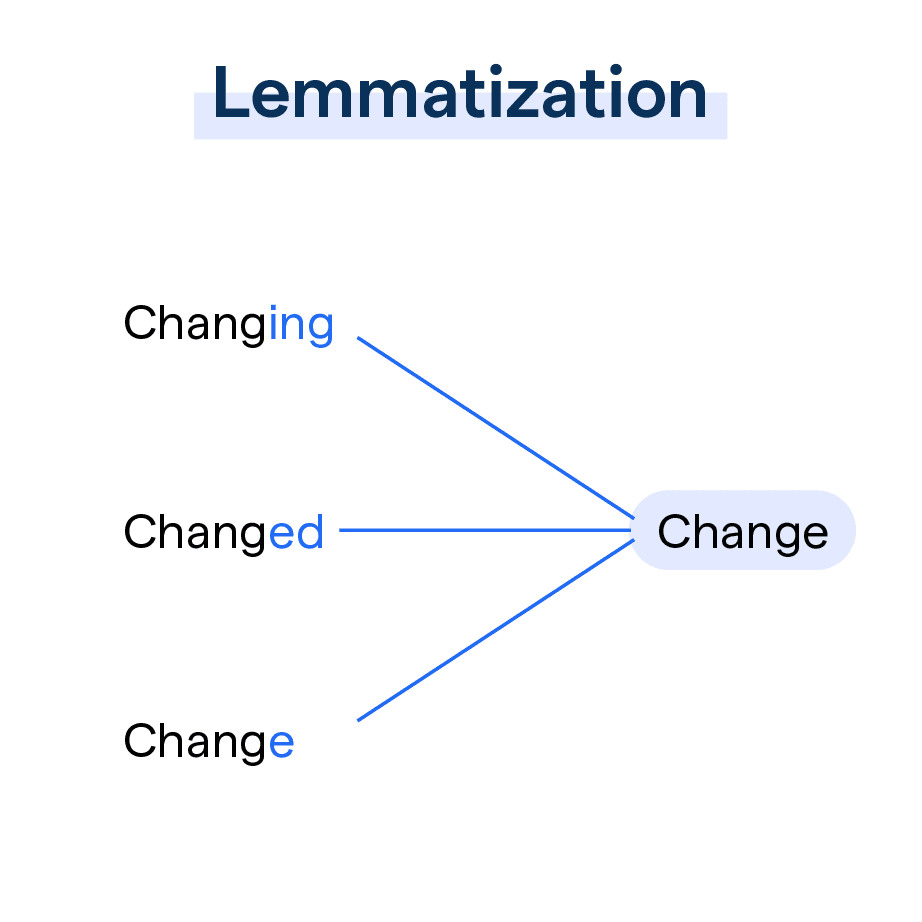
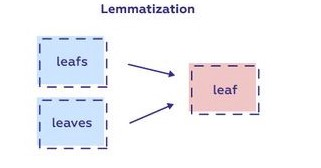

In [99]:
import spacy

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue

        if token.text.startswith("<") and token.text.endswith(">"):
            lemmas.append(token.text)
            continue

        lemma = token.lemma_.lower()
        lemmas.append(lemma)

    return " ".join(lemmas)

nlp = spacy.load("en_core_web_sm")
ex_lem = df_num["after_number_norm"].copy()
examples_lem_norm = ex_lem.apply(lemmatize_text)
df_lem = pd.DataFrame({"original": ex_lem.values,"lemmatization": examples_lem_norm.values})
df_lem.head()

,original,lemmatization
0,renaissance man at the rio theatre - santa cruz news <url>,renaissance man at the rio theatre - santa cruz news < url >
1,"the horrible aftermath of sandy in harlem, nyc! <url>","the horrible aftermath of sandy in harlem , nyc ! < url >"
2,"after the chile quake: unease, and wedding bells, in santiago - time <url>","after the chile quake : unease , and wedding bell , in santiago - time < url >"
3,halloween <num> ( frankenstorm apocalypse - hurricane sandy w/ <num> others) <url>,halloween < num > ( frankenstorm apocalypse - hurricane sandy w/ < num > other ) < url >
4,"some people may be happy to see a walmart boarded up, but not for this reason. sandy walmart <url>","some people may be happy to see a walmart board up , but not for this reason . sandy walmart < url >"


To lemmatize the messages in the dataset, I created the `lemmatize_text` function, which uses the loaded English spaCy model to extract lemmatized tokens from the passed texts, while skipping spaces, so they are not counted as separate words. Then, it checks for special tokens starting with "<" and ending wiht ">" to prevent lemmatizing them. For all normal words, it takes their base forms and adds them to the list. Lastly, all lemmas are joined with spaces and return as a single string.

## Term Frequency - Inverse Document Frequency
TF-IDF is a statistical method used in natural language preprocessing to measure how important a word is.
 - *Term Frequency* - measures how important a word is in a message; the more the word appear, the greater importance it has
 - *Inverse Document Frequency* - measures how rare a word is across all given messages

The final weight is based on the terms above -  the more frequently a word appears in a message and the least frequently it appears across the whole dataset, the higher its final TF-IDF will be. In the example below, I use the small dataset with lemmatized samples to show how TF-IDF works. First, I fit the vectorizer on the small dataset, so it can learn which tokens appears often and assess how rare it is. Then, I select one message and extract its TF-IDF vector results. I filter the samples with non-zero weights. Lastly, I sort the top 10 weights, starting from the most important one.

In [144]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

texts = df_lem["lemmatization"].tolist()
vectorizer = TfidfVectorizer(ngram_range=(1, 2),max_features=10000,stop_words="english",min_df=3)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

tfidf_row    = X_tfidf[100].toarray()[0]
nonzero_idx = np.where(tfidf_row > 0)[0]
token_weights = [(feature_names[i], tfidf_row[i]) for i in nonzero_idx]
token_weights_sorted = sorted(token_weights, key=lambda x: x[1], reverse=True)
top10 = token_weights_sorted[:10]

df_tfidf_example = pd.DataFrame(top10, columns=["token", "tfidf_weight"])
df_tfidf_example

,token,tfidf_weight
0,help,0.285351
1,donation num,0.259758
2,num help,0.259758
3,want help,0.259758
4,haiti info,0.250537
5,victim haiti,0.250537
6,help earthquake,0.236632
7,help http,0.231114
8,info,0.231114
9,unicef,0.226247


From the table above, we can see that the TF-IDF assigns words like "help", "donation num" and "num help" as top 3 most important words for this message. The results suggest that the message is dominated by requests for help and donations, specifically related to the victims of the haiti earthquake.